In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import re
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
import os

In [15]:
users = pd.read_parquet('cert_dataset/users.parquet')
users['start_date'] = pd.to_datetime(users['start_date'])
users['end_date'] = pd.to_datetime(users['end_date'])
users.head()

,employee_name,user_id,email,role,projects,business_unit,functional_unit,department,team,supervisor,start_date,end_date
0,Nicholas Fletcher Pruitt,NFP2441,Nicholas.Fletcher.Pruitt@dtaa.com,ITAdmin,None,1,1 - Adminstration,5 - Security,8 - ElectronicSecurity,Madison Charissa Malone,2009-12-01,2011-06-01
1,Abraham Dante Rodgers,ADR1517,Abraham.Dante.Rodgers@dtaa.com,ProductionLineWorker,None,1,5 - Manufacturing_Commercial,3 - Assembly,4 - AssemblyDept,Mark William Horne,2009-12-01,2011-06-01
2,Medge Wilma Blackburn,MWB4000,Medge.Wilma.Blackburn@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,14 - AssemblyDept,Hillary Zenaida Adkins,2009-12-01,2011-06-01
3,Meghan Laurel Salazar,MLS2856,Meghan.Laurel.Salazar@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,8 - AssemblyDept,Demetria Sage Melendez,2009-12-01,2011-06-01
4,Beau Todd Romero,BTR2026,Beau.Todd.Romero@dtaa.com,MechanicalEngineer,None,1,3 - ResearchAndEngineering_Government_Domestic,4 - Engineering,16 - TestAndEvalualtion,Elijah Valentine Fuentes,2009-12-01,2011-06-01


In [16]:
users['end_date'] = pd.to_datetime(users['end_date'])
users_left = users[users['end_date'] != pd.to_datetime('2011-06-01')]
print(len(users_left))

361


### EMAIL FEATURES

In [28]:
email = pd.read_parquet("cert_dataset/email.parquet")
email.head()

,id,date,user,pc,to,cc,bcc,from,activity,size,attachments,content
0,{I1O2-B4EB49RW-7379WSQW},01/02/2010 06:36:41,HDB1666,PC-6793,Louis.Bernard.Garza@dtaa.com,Emery.Ali.Holloway@dtaa.com,Hector.Donovan.Bray@dtaa.com,Hector.Donovan.Bray@dtaa.com,Send,45659,None,"Now Sylvia, the object of Aminta's desire, arr..."
1,{L7E7-V4UX89RR-3036ZDHU},01/02/2010 06:40:02,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Luke.Grant.Mcmahon@dtaa.com,View,34142,None,"On May 14, they picked up 44 more Iroquois at ..."
2,{S8C2-Q8YX87DJ-0516SIWZ},01/02/2010 06:42:48,HDB1666,PC-6793,Quintessa.O.Farrell@harris.com,Hector.Donovan.Bray@dtaa.com,None,Hector.Donovan.Bray@dtaa.com,Send,1310925,C:\28X79b6\0PAGXTJ8.doc(1119253);C:\11b38g6\5M...,Sylvia is notable for its mythological Arcadia...
3,{A1V9-O5BL46SW-1708NAEC},01/02/2010 06:45:42,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Travis.Ezra.Warner@dtaa.com,View,23043,None,Lanctot (1967) and Smith do not identify any s...
4,{N6R0-M2EI82DM-5583LSUM},01/02/2010 06:47:07,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Kenyon.William.Delacruz@dtaa.com,View,25210,None,Much like all the other large groups of prison...


In [29]:
suspicious_keywords = [
    'jobsearch','job search','security clearance','contingent upon award',
    'position requires','apply now','bachelor degree','job opening',

    'resignation', 'two weeks notice', 'last day',
    'offer letter', 'new position',
    'keylogger','free keylogger','computer monitoring','monitoring software','spyware','trojan',
    'rootkit','RAT','remote access tool','payload','botnet',

    'do not share', 'do not forward',
    'internal only', 'not for distribution',
    'keep this between', 'off the record',

    'my password is', 'login credentials',
    'api key', 'private key', 'ssh key',
    'access token', 'secret key',

    'delete after reading', 'do not tell',
    'just between us', 'they will never know',
]

pattern = '|'.join(suspicious_keywords)

email['has_suspicious_content'] =(email['content'].str.lower().str.contains(pattern,na=False).astype(int))  

In [30]:
email['date'] = pd.to_datetime(email['date'], format='%m/%d/%Y %H:%M:%S')
email = email.drop(columns=['id'])
email = email.sort_values(by='date')
email.head()

,date,user,pc,to,cc,bcc,from,activity,size,attachments,content,has_suspicious_content
0,2010-01-02 06:36:41,HDB1666,PC-6793,Louis.Bernard.Garza@dtaa.com,Emery.Ali.Holloway@dtaa.com,Hector.Donovan.Bray@dtaa.com,Hector.Donovan.Bray@dtaa.com,Send,45659,None,"Now Sylvia, the object of Aminta's desire, arr...",0
1,2010-01-02 06:40:02,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Luke.Grant.Mcmahon@dtaa.com,View,34142,None,"On May 14, they picked up 44 more Iroquois at ...",0
2,2010-01-02 06:42:48,HDB1666,PC-6793,Quintessa.O.Farrell@harris.com,Hector.Donovan.Bray@dtaa.com,None,Hector.Donovan.Bray@dtaa.com,Send,1310925,C:\28X79b6\0PAGXTJ8.doc(1119253);C:\11b38g6\5M...,Sylvia is notable for its mythological Arcadia...,0
3,2010-01-02 06:45:42,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Travis.Ezra.Warner@dtaa.com,View,23043,None,Lanctot (1967) and Smith do not identify any s...,0
4,2010-01-02 06:47:07,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Kenyon.William.Delacruz@dtaa.com,View,25210,None,Much like all the other large groups of prison...,0


In [31]:
domain = '@dtaa.com'
email['is_external'] = (
    (~email['from'].str.contains(domain, na=False)) |
    (~email['to'].str.contains(domain, na=False))
)
email['has_bcc'] = email['bcc'].notna() & (email['bcc'] != 'None')

email['has_attachment'] = email['attachments'].notna() & (email['attachments'] != 'None')

email['is_external_with_attachment'] = email['is_external'] & email['has_attachment']

email['week'] = email['date'].dt.to_period('W')

email['month'] = email['date'].dt.to_period('M')

email['is_after_hours'] = ( (email['date'].dt.hour > 19) | (email['date'].dt.hour < 7))

email['is_weekend'] = email['date'].dt.dayofweek >= 5

email['is_weekend_or_after_hours'] = email['is_weekend'] | email['is_after_hours']

email['nb_attachments'] = email['attachments'].apply(
    lambda x : len(x.split(';')) if pd.notna(x) and x != None else 0
)

email.head()

,date,user,pc,to,cc,bcc,from,activity,size,attachments,...,is_external,has_bcc,has_attachment,is_external_with_attachment,week,month,is_after_hours,is_weekend,is_weekend_or_after_hours,nb_attachments
0,2010-01-02 06:36:41,HDB1666,PC-6793,Louis.Bernard.Garza@dtaa.com,Emery.Ali.Holloway@dtaa.com,Hector.Donovan.Bray@dtaa.com,Hector.Donovan.Bray@dtaa.com,Send,45659,None,...,False,True,False,False,2009-12-28/2010-01-03,2010-01,True,True,True,0
1,2010-01-02 06:40:02,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Luke.Grant.Mcmahon@dtaa.com,View,34142,None,...,False,False,False,False,2009-12-28/2010-01-03,2010-01,True,True,True,0
2,2010-01-02 06:42:48,HDB1666,PC-6793,Quintessa.O.Farrell@harris.com,Hector.Donovan.Bray@dtaa.com,None,Hector.Donovan.Bray@dtaa.com,Send,1310925,C:\28X79b6\0PAGXTJ8.doc(1119253);C:\11b38g6\5M...,...,True,False,True,True,2009-12-28/2010-01-03,2010-01,True,True,True,2
3,2010-01-02 06:45:42,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Travis.Ezra.Warner@dtaa.com,View,23043,None,...,False,False,False,False,2009-12-28/2010-01-03,2010-01,True,True,True,0
4,2010-01-02 06:47:07,HDB1666,PC-6793,Hector.Donovan.Bray@dtaa.com,None,None,Kenyon.William.Delacruz@dtaa.com,View,25210,None,...,False,False,False,False,2009-12-28/2010-01-03,2010-01,True,True,True,0


In [32]:
df_left = email[email['user'].isin(users_left['user_id'])][['user', 'date', 'activity']].copy()

df_left = df_left.merge(
    users_left[['user_id', 'end_date']],
    left_on='user',
    right_on='user_id',
    how='left'
).drop(columns='user_id')



df_left['is_after_leaving'] = df_left['date'] > df_left['end_date']
df_left

,user,date,activity,end_date,is_after_leaving
0,MBA1797,2010-01-02 07:04:25,Send,2010-10-01,False
1,MBA1797,2010-01-02 07:08:36,View,2010-10-01,False
2,MBA1797,2010-01-02 07:25:24,Send,2010-10-01,False
3,MBA1797,2010-01-02 07:26:59,View,2010-10-01,False
4,MBA1797,2010-01-02 07:30:15,View,2010-10-01,False
...,...,...,...,...,...
518387,OCD3513,2011-05-19 14:14:19,View,2011-05-01,True
518388,OCD3513,2011-05-19 16:10:17,Send,2011-05-01,True
518389,OCD3513,2011-05-19 16:26:14,View,2011-05-01,True
518390,OCD3513,2011-05-19 16:30:37,Send,2011-05-01,True


In [33]:
nb_activity_email_after_left = df_left.groupby('user').agg(
    email_nb_activity_email_after_leaving = ('is_after_leaving', 'sum')
).reset_index()

In [34]:
email_most_used_pc = (
    email.groupby(['user','pc'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
    .groupby('user')
    .first()
    .reset_index()[['user','pc']]
    .rename(columns={'pc':'most_used_pc'})
)

In [ ]:
features_email = email.groupby('user').agg(
    email_nb_emails = ('date','count'),
    email_nb_emails_sent = ('activity',lambda x : (x=='Send').sum()),
    email_nb_emails_viewed = ('activity',lambda x : (x=='View').sum()),
    email_nb_external = ('is_external','sum'),
    email_nb_bcc = ('has_bcc','sum'),
    email_nb_external_with_attachment = ('is_external_with_attachment','sum'),
    email_nb_after_hours_or_weekend = ('is_weekend_or_after_hours','sum'),
    email_nb_emails_has_suspicious_content = ('has_suspicious_content','sum')
).reset_index()

features_email['email_external_ratio'] = (
    features_email['email_nb_external'] / features_email['email_nb_emails']
)

features_email['email_suspicious_content_ratio'] = (
    features_email['email_nb_emails_has_suspicious_content'] / features_email['email_nb_emails']
)

features_email['email_bcc_email_ratio'] = (
    features_email['email_nb_bcc'] / features_email['email_nb_emails']
)
features_email['email_external_email_with_attachment_ratio'] = (
    features_email['email_nb_external_with_attachment'] / features_email['email_nb_emails']
)
features_email['email_after_hours_or_weekend_ratio'] = (
    features_email['email_nb_after_hours_or_weekend'] / features_email['email_nb_emails']
)

emails_per_week = email.groupby(['user', 'week']).size().reset_index(name='email_nb_emails_week')

weekly_email_activity = email.groupby(['user', 'week']).agg(
    nb_emails = ('activity','count'),
    nb_emails_sent = ('activity',lambda x : (x=='Send').sum()) 
).reset_index()

email_baseline = weekly_email_activity.groupby('user').agg(
    baseline_median_emails = ('nb_emails','median'),
    baseline_median_emails_sent = ('nb_emails_sent','median'),
    baseline_std_emails = ('nb_emails','std'),
    baseline_std_emails_sent = ('nb_emails_sent','std'),
)

weekly_email_activity = weekly_email_activity.merge(email_baseline,on='user',how='left')

weekly_email_activity['zscore_emails'] = (
    (weekly_email_activity['nb_emails'] - weekly_email_activity['baseline_median_emails']) / weekly_email_activity['baseline_std_emails'].clip(lower=1)
)

weekly_email_activity['zscore_emails_sent'] = (
    (weekly_email_activity['nb_emails_sent'] - weekly_email_activity['baseline_median_emails_sent']) / weekly_email_activity['baseline_std_emails_sent'].clip(lower=1)
)

zscore_email_features = weekly_email_activity.groupby('user').agg(
    email_max_zscore_emails      = ('zscore_emails', 'max'),
    email_max_zscore_emails_sent = ('zscore_emails_sent', 'max'),
).reset_index()

features_email = features_email.merge(zscore_email_features, on='user', how='left')

avg_emails_per_week = emails_per_week.groupby('user')['email_nb_emails_week'].mean().reset_index()

avg_emails_per_week.columns = ['user', 'email_avg_emails_per_week']

features_email = features_email.merge(avg_emails_per_week, on='user', how='left')

sent_emails = email[email['activity'] == 'Send']

features_sent = sent_emails.groupby('user').agg(
    email_avg_size_sent_email            = ('size', 'mean'),  
).reset_index()
features_email = features_email.merge(features_sent, on='user', how='left')

last_month_activity = email.groupby(['user', 'month']).size().reset_index(name='nb_emails_month')

last_month = (
    last_month_activity
    .sort_values(['user', 'month'])
    .groupby('user', as_index=False)
    .tail(1)
)[['user', 'nb_emails_month']]

last_month.rename(columns={'nb_emails_month': 'email_nb_emails_last_month'}, inplace=True)

last_month.loc[
    ~last_month['user'].isin(users_left['user_id']),
    'email_nb_emails_last_month'
] = 0

features_email = features_email.merge(last_month, on='user', how='left')
features_email['email_nb_emails_last_month'] = features_email['email_nb_emails_last_month'].fillna(0)

features_email = features_email.merge(nb_activity_email_after_left, on='user', how='left')

features_email['email_nb_activity_email_after_leaving'] = (
    features_email['email_nb_activity_email_after_leaving'].fillna(0).astype(int)
)

email_events_with_main_pc = email.merge(email_most_used_pc,on='user',how='left')

email_not_main_pc = (
    email_events_with_main_pc
    .groupby('user')
    .apply(lambda x:(x['pc'] != x['most_used_pc']).sum(),include_groups=False)
    .reset_index(name='email_nb_email_not_main_pc')
)

features_email = features_email.merge(email_not_main_pc, on='user', how='left')
features_email['email_nb_email_not_main_pc_ratio'] = features_email['email_nb_email_not_main_pc'] / features_email['email_nb_emails']

features_email.head() 

,user,email_nb_emails,email_nb_emails_sent,email_nb_emails_viewed,email_nb_external,email_nb_bcc,email_nb_external_with_attachment,email_nb_after_hours_or_weekend,email_nb_emails_has_suspicious_content,email_external_ratio,...,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_max_zscore_emails_sent,email_avg_emails_per_week,email_avg_size_sent_email,email_nb_emails_last_month,email_nb_activity_email_after_leaving,email_nb_email_not_main_pc,email_nb_email_not_main_pc_ratio
0,AAB0162,3146,1122,2024,967,0,161,0,47,0.307374,...,0.051176,0.000000,0.0,1.843913,42.513514,1.994349e+05,0,0,0,0.0
1,AAB0398,3811,1348,2463,1462,0,450,215,14,0.383626,...,0.118079,0.056416,0.0,2.314657,51.500000,3.568791e+05,0,0,0,0.0
2,AAC0610,1052,388,664,382,0,139,0,10,0.363118,...,0.132129,0.000000,0.0,2.661585,14.216216,8.273392e+05,0,0,0,0.0
3,AAC0668,3115,1093,2022,1092,0,219,0,24,0.350562,...,0.070305,0.000000,0.0,2.145350,42.094595,4.068177e+05,0,0,0,0.0
4,AAC3270,344,120,224,89,0,48,0,0,0.258721,...,0.139535,0.000000,0.0,2.951763,4.648649,1.333953e+06,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ADV2467,3118,1069,2049,1057,0,121,0,15,0.338999,...,0.038807,0.000000,0.0,1.854315,42.135135,3.040914e+04,0,0,0,0.0
96,ADW2832,346,127,219,133,0,26,6,2,0.384393,...,0.075145,0.017341,0.0,2.525100,4.675676,2.972957e+04,0,0,0,0.0
97,AEB1458,3124,1095,2029,1130,0,308,0,16,0.361716,...,0.098592,0.000000,0.0,2.133960,42.216216,8.216172e+05,0,0,0,0.0
98,AEB3249,3156,1068,2088,1310,511,183,0,11,0.415082,...,0.057985,0.000000,0.0,1.752002,42.648649,2.375555e+05,0,0,0,0.0


In [2]:
logon = pd.read_parquet("cert_dataset/logon.parquet")
logon.head()

,id,date,user,pc,activity
0,{F3X8-Y2GT43DR-4906OHBL},01/02/2010 02:19:18,DNS1758,PC-0414,Logon
1,{B4Q0-D0GM24KN-3704MAII},01/02/2010 02:31:12,DNS1758,PC-0414,Logoff
2,{T7J1-D4HK34KV-5476TCIJ},01/02/2010 02:34:02,DNS1758,PC-5313,Logon
3,{S4Y6-D8MQ05SA-0759HLIS},01/02/2010 02:53:30,DNS1758,PC-5313,Logoff
4,{F3P0-E7FH78CV-4874FRGZ},01/02/2010 04:07:31,DNS1758,PC-0012,Logon


In [3]:
logon['date'] = pd.to_datetime(logon['date'], format='%m/%d/%Y %H:%M:%S')
logon = logon.drop(columns=['id'])
logon = logon.sort_values(by='date')
logon.head()

,date,user,pc,activity
0,2010-01-02 02:19:18,DNS1758,PC-0414,Logon
1,2010-01-02 02:31:12,DNS1758,PC-0414,Logoff
2,2010-01-02 02:34:02,DNS1758,PC-5313,Logon
3,2010-01-02 02:53:30,DNS1758,PC-5313,Logoff
4,2010-01-02 04:07:31,DNS1758,PC-0012,Logon


In [4]:
logon['is_after_hours'] = ( (logon['date'].dt.hour > 19) | (logon['date'].dt.hour < 7))
logon['week'] = logon['date'].dt.to_period('W')
logon['month'] = logon['date'].dt.to_period('M')
logon_events = logon[logon['activity'] == 'Logon'].sort_values(by=['user','date']).copy()
logoff_events = logon[logon['activity'] == 'Logoff'].sort_values(by=['user','date']).copy()

logon_events['rank'] = logon_events.groupby('user').cumcount()
logoff_events['rank'] = logoff_events.groupby('user').cumcount()

sessions = pd.merge(
    logon_events[['user','rank','pc','date']],
    logoff_events[['user','rank','date']],
    on=['user','rank'],
    suffixes=['_start','_end']
)

sessions['duration_hours'] = (
    sessions['date_end'] - sessions['date_start']
).dt.total_seconds() / 3600

sessions = sessions[(sessions['duration_hours'] > 0) & (sessions['duration_hours'] < 24)]


In [8]:
logon_left = logon[logon['user'].isin(users_left['user_id'])][['user', 'date', 'activity']].copy() 

logon_left = logon_left.merge(
    users_left[['user_id', 'end_date']],
    left_on='user',
    right_on='user_id',
    how='left'
).drop(columns='user_id')



logon_left['is_after_leaving'] = logon_left['date'] > logon_left['end_date']
logon_left.head()

,user,date,activity,end_date,is_after_leaving
0,SFC2336,2010-01-02 07:02:00,Logon,2010-09-01,False
1,MBA1797,2010-01-02 07:03:00,Logon,2010-10-01,False
2,JPC2507,2010-01-02 07:04:00,Logon,2010-06-01,False
3,JKS2444,2010-01-02 07:16:00,Logon,2010-08-01,False
4,LXE2139,2010-01-02 07:28:00,Logon,2011-01-01,False


In [9]:
nb_logon_after_left = logon_left.groupby('user').agg(
    logon_nb_logon_after_leaving = ('is_after_leaving', 'sum')
).reset_index()

In [10]:
features_sessions = sessions.groupby('user').agg(
    logon_average_session_duration     = ('duration_hours', 'mean'),
    logon_session_duration_variability = ('duration_hours', 'std'),
    logon_nb_sessions                  = ('duration_hours', 'count'),
    logon_nb_short_sessions            = ('duration_hours', lambda x: (x < 0.1).sum()),
).reset_index()

features_sessions['logon_ratio_short_sessions'] = (
    features_sessions['logon_nb_short_sessions'] / features_sessions['logon_nb_sessions']
)

logon_events['prev_activity'] = logon_events.groupby('user')['activity'].shift(1)
logon_events['prev_pc']       = logon_events.groupby('user')['pc'].shift(1)

suspicious_multipc = logon_events[
    (logon_events['activity'] == 'Logon') &
    (logon_events['prev_activity'] == 'Logon') &
    (logon_events['pc'] != logon_events['prev_pc'])
]

multi_pc_users = suspicious_multipc['user'].unique()

features_sessions['logon_used_multi_pc_simultaneously'] = (
    features_sessions['user'].isin(multi_pc_users).astype(int)
)

features_sessions['logon_session_duration_variability'] = (
    features_sessions['logon_session_duration_variability'].fillna(0).astype(int)
)


features_sessions.head()

,user,logon_average_session_duration,logon_session_duration_variability,logon_nb_sessions,logon_nb_short_sessions,logon_ratio_short_sessions,logon_used_multi_pc_simultaneously
0,AAB0162,11.061421,0,251,0,0.0,0
1,AAB0398,9.092884,0,356,0,0.0,0
2,AAC0610,9.100000,0,2,0,0.0,0
3,AAC0668,9.080852,0,356,0,0.0,0
4,AAC3270,8.080290,0,356,0,0.0,0


In [19]:
most_used_pc = (
    logon_events.groupby(['user','pc'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
    .groupby('user')
    .first()
    .reset_index()[['user','pc']]
    .rename(columns={'pc':'most_used_pc'})
)

In [22]:
logon_features = logon.groupby('user').agg(
    logon_nb_logon = ('activity',lambda x : (x=='Logon').sum()),
    logon_nb_logoff = ('activity',lambda x : (x=='Logoff').sum()),
    logon_nb_pc_used = ('pc','nunique'),
    logon_nb_pc_used_logon = ('pc',lambda x : x[logon.loc[x.index,'activity']=='Logon'].nunique()),
    logon_nb_after_hours_logon = ('activity',lambda x : ((x=='Logon')&(logon.loc[x.index,'is_after_hours']==True)).sum()),
).reset_index()     

logon_features['logon_unclosed_session_ratio'] = ((logon_features['logon_nb_logon'] - logon_features['logon_nb_logoff']).clip(lower=0) / logon_features['logon_nb_logon']).fillna(0)
logon_features['logon_after_hours_logon_ratio'] = (logon_features['logon_nb_after_hours_logon'] / logon_features['logon_nb_logon']).fillna(0)

weekly_logon_activity = logon_events.groupby(['user', 'week']).agg(
    nb_logon = ('activity','count'),
    nb_logon_after_hours = ('is_after_hours','sum') 
).reset_index()

logon_baseline = weekly_logon_activity.groupby('user').agg(
    baseline_median_logon = ('nb_logon','median'),
    baseline_median_logon_after_hours = ('nb_logon_after_hours','median'),
    baseline_std_logon = ('nb_logon','std'),
    baseline_std_logon_after_hours = ('nb_logon_after_hours','std'),
)

weekly_logon_activity = weekly_logon_activity.merge(logon_baseline,on='user',how='left')

weekly_logon_activity['logon_zscore_logon'] = (
    (weekly_logon_activity['nb_logon'] - weekly_logon_activity['baseline_median_logon']) / weekly_logon_activity['baseline_std_logon'].clip(lower=1)
)

weekly_logon_activity['logon_zscore_logon_after_hours'] = (
    (weekly_logon_activity['nb_logon_after_hours'] - weekly_logon_activity['baseline_median_logon_after_hours']) / weekly_logon_activity['baseline_std_logon_after_hours'].clip(lower=1)
)

zscore_logon_features = weekly_logon_activity.groupby('user').agg(
    logon_max_zscore_logon      = ('logon_zscore_logon', 'max'),
    logon_max_zscore_logon_after_hours = ('logon_zscore_logon_after_hours', 'max'),
).reset_index()

logon_features = logon_features.merge(zscore_logon_features, on='user', how='left')

last_month_activity = logon.groupby(['user', 'month']).size().reset_index(name='nb_logon_month')

last_month = (
    last_month_activity
    .sort_values(['user', 'month'])
    .groupby('user', as_index=False)
    .tail(1)
)[['user', 'nb_logon_month']]

last_month.rename(columns={'nb_logon_month': 'logon_nb_logon_last_month'}, inplace=True)

last_month.loc[
    ~last_month['user'].isin(users_left['user_id']),
    'logon_nb_logon_last_month'
] = 0

logon_features = logon_features.merge(last_month, on='user', how='left')

logon_features = logon_features.merge(nb_logon_after_left, on='user', how='left')

logon_features['logon_nb_logon_after_leaving'] = (
    logon_features['logon_nb_logon_after_leaving'].fillna(0)
)

logon_events_with_main_pc = logon_events.merge(most_used_pc,on='user',how='left')

logon_not_main_pc = (
    logon_events_with_main_pc
    .groupby('user')
    .apply(lambda x:(x['pc'] != x['most_used_pc']).sum(),include_groups=False)
    .reset_index(name='logon_nb_logon_not_main_pc')
)

logon_features = logon_features.merge(logon_not_main_pc, on='user', how='left')
logon_features['logon_nb_logon_not_main_pc_ratio'] = logon_features['logon_nb_logon_not_main_pc'] / logon_features['logon_nb_logon']
logon_features.head()

,user,logon_nb_logon,logon_nb_logoff,logon_nb_pc_used,logon_nb_pc_used_logon,logon_nb_after_hours_logon,logon_unclosed_session_ratio,logon_after_hours_logon_ratio,logon_max_zscore_logon,logon_max_zscore_logon_after_hours,logon_nb_logon_last_month,logon_nb_logon_after_leaving,logon_nb_logon_not_main_pc,logon_nb_logon_not_main_pc_ratio
0,AAB0162,355,356,1,1,0,0.000000,0.000000,0.00000,0.0,0,0.0,0,0.0
1,AAB0398,356,356,1,1,356,0.000000,1.000000,0.00000,0.0,0,0.0,0,0.0
2,AAC0610,665,387,1,1,28,0.418045,0.042105,2.02017,3.0,0,0.0,0,0.0
3,AAC0668,356,356,1,1,0,0.000000,0.000000,0.00000,0.0,0,0.0,0,0.0
4,AAC3270,356,356,1,1,0,0.000000,0.000000,0.00000,0.0,0,0.0,0,0.0


In [36]:
decoy_file = pd.read_parquet("cert_dataset/decoy_file.parquet")
decoy_file.head()

,decoy_filename,pc
0,C:\LJE2413\795JW126.jpg,PC-0302
1,C:\QMU9BC38.pdf,PC-6566
2,C:\GIS1668\YPS1RSIK.jpg,PC-2606
3,C:\KD02AETE.pdf,PC-5393
4,C:\AUZTDD4J.jpg,PC-8753


In [37]:
file = pd.read_parquet("cert_dataset/file.parquet")
file.head()

,id,date,user,pc,filename,activity,to_removable_media,from_removable_media,content
0,{F3E2-X3MV05YQ-3516SZDT},01/02/2010 07:19:41,SDH2394,PC-5849,R:\60WBQE7S.doc,File Open,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
1,{I6N1-Z7VL92UY-8715ESKQ},01/02/2010 07:21:30,SDH2394,PC-5849,R:\0VGILDW8.pdf,File Write,True,False,25-50-44-46-2D ---- Bengali As do many other T...
2,{G4X5-J7MH70FV-8936QVSB},01/02/2010 07:22:11,SDH2394,PC-5849,R:\60WBQE7S.doc,File Copy,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
3,{M2M7-Z5ST21EU-6704NSKO},01/02/2010 07:24:06,SDH2394,PC-5849,R:\22B5gX4\H8Y96RRE.doc,File Write,True,False,D0-CF-11-E0-A1-B1-1A-E1 After the death of his...
4,{R0A9-O9XB25PE-9236MALV},01/02/2010 07:24:45,SDH2394,PC-5849,R:\SDH2394\7XRCV2N5.pdf,File Copy,True,False,25-50-44-46-2D Although he restored some of th...


In [38]:
file_decoy = file[file['filename'].isin(decoy_file['decoy_filename'])]
file_decoy = file_decoy[['user','pc','filename']]
file_decoy.head()

,user,pc,filename
11,ABM3641,PC-7385,C:\77h89S6\DQSH4LBO.doc
15,AXW3243,PC-4929,C:\NTFU9CKZ.doc
21,HID1899,PC-2433,C:\386lN89\F868J5R7.pdf
22,DJA0740,PC-7197,C:\AS31ZQDZ.doc
25,ANC1950,PC-4921,C:\ANC1950\AIG3BQT7.pdf


In [39]:
file_decoy_features = file_decoy.groupby('user').agg(
    decoy_file_nb_access_decoy_file = ('filename','count'),
    decoy_file_nb_pc_decoy_file = ('pc','nunique')
).reset_index()

file_decoy_features.head()

,user,decoy_file_nb_access_decoy_file,decoy_file_nb_pc_decoy_file
0,AAB0162,30,1
1,AAB0398,36,1
2,AAC0610,191,1
3,AAC0668,62,1
4,AAC3270,8,1


### File Features

In [22]:
file = pd.read_parquet("cert_dataset/file.parquet")
file.head()

,id,date,user,pc,filename,activity,to_removable_media,from_removable_media,content
0,{F3E2-X3MV05YQ-3516SZDT},01/02/2010 07:19:41,SDH2394,PC-5849,R:\60WBQE7S.doc,File Open,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
1,{I6N1-Z7VL92UY-8715ESKQ},01/02/2010 07:21:30,SDH2394,PC-5849,R:\0VGILDW8.pdf,File Write,True,False,25-50-44-46-2D ---- Bengali As do many other T...
2,{G4X5-J7MH70FV-8936QVSB},01/02/2010 07:22:11,SDH2394,PC-5849,R:\60WBQE7S.doc,File Copy,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
3,{M2M7-Z5ST21EU-6704NSKO},01/02/2010 07:24:06,SDH2394,PC-5849,R:\22B5gX4\H8Y96RRE.doc,File Write,True,False,D0-CF-11-E0-A1-B1-1A-E1 After the death of his...
4,{R0A9-O9XB25PE-9236MALV},01/02/2010 07:24:45,SDH2394,PC-5849,R:\SDH2394\7XRCV2N5.pdf,File Copy,True,False,25-50-44-46-2D Although he restored some of th...


In [40]:
file['date'] = pd.to_datetime(file['date'], format='%m/%d/%Y %H:%M:%S')
file = file.drop(columns=['id'])
file = file.sort_values(by='date')

In [41]:
file['is_copy']   = file['activity'] == 'File Copy'
file['is_write']  = file['activity'] == 'File Write'
file['is_delete'] = file['activity'] == 'File Delete'
file['week'] = file['date'].dt.to_period('W')
file['to_rem']   = file['to_removable_media']
file['from_rem'] = file['from_removable_media']
file['month'] = file['date'].dt.to_period('M')
file['is_weekend']    = file['date'].dt.dayofweek >= 5
file['is_after_hours'] = ~file['date'].dt.hour.between(7, 19)
file['is_off_hours']  = file['is_weekend'] | file['is_after_hours']

file = file.sort_values(['user', 'filename', 'date'])

file['prev_activity'] = file.groupby(['user', 'filename'])['activity'].shift(1)

file['open_then_copy']    = file['is_copy']   & (file['prev_activity'] == 'File Open')
file['write_then_delete'] = file['is_delete'] & (file['prev_activity'] == 'File Write')
file['copy_then_delete']  = file['is_delete'] & (file['prev_activity'] == 'File Copy')


file['copy_to_rem']  = file['is_copy']  & file['to_rem']
file['write_to_rem'] = file['is_write'] & file['to_rem']

In [42]:
SUSPICIOUS_KEYWORDS = [
    'jobsearch', 'job search', 'security clearance',
    'contingent upon award', 'apply now', 'job opening',
    'apply online', 'position requires', 'upload your resume',
    'click apply', 'career opportunities',

    'keylogger', 'free keylogger', 'computer monitoring',
    'monitoring software', 'spyware', 'trojan', 'rootkit',
    'remote access tool', 'payload', 'botnet',

    'my password is', 'login credentials', 'api key',
    'private key', 'ssh key', 'access token', 'secret key',

    'delete after reading', 'do not tell',
    'just between us', 'they will never know',
    'do not share', 'do not forward',
    'internal only', 'not for distribution',
]

SUSPICIOUS_FILENAMES = [
    r'\.exe$', r'\.bat$', r'\.ps1$', r'\.vbs$',
    r'\.dll$', r'\.sh$', r'\.cmd$', r'\.msi$',
    r'keylogger', r'malware', r'exploit', r'payload',
    r'backdoor', r'rootkit', r'trojan', r'rat\.',
]

pattern_content  = r'\b(?:' + '|'.join(map(re.escape, SUSPICIOUS_KEYWORDS)) + r')\b'
pattern_filename = '|'.join(SUSPICIOUS_FILENAMES)

file['has_suspicious_content'] = file['content'].str.contains(
    pattern_content, case=False, na=False, regex=True
)

file['has_suspicious_filename'] = file['filename'].str.contains(
    pattern_filename, case=False, na=False, regex=True
)

file['is_suspicious'] = file['has_suspicious_content'] | file['has_suspicious_filename']

In [43]:
file_left = file[file['user'].isin(users_left['user_id'])][['user', 'date', 'activity']].copy()

file_left = file_left.merge(
    users_left[['user_id', 'end_date']],
    left_on='user',
    right_on='user_id',
    how='left'
).drop(columns='user_id')

file_left['is_after_leaving'] = file_left['date'] > file_left['end_date']
file_left.head()

,user,date,activity,end_date,is_after_leaving
0,ABB0167,2010-01-15 16:19:34,File Open,2010-08-01,False
1,ABB0167,2010-06-09 13:24:17,File Open,2010-08-01,False
2,ABB0167,2010-01-12 15:07:12,File Open,2010-08-01,False
3,ABB0167,2010-01-25 16:51:23,File Open,2010-08-01,False
4,ABB0167,2010-02-04 15:12:57,File Open,2010-08-01,False


In [44]:
nb_file_after_leaving = file_left.groupby('user').agg(
    file_nb_file_after_leaving = ('is_after_leaving', 'sum')
).reset_index()

In [45]:
file_most_used_pc = (
    file.groupby(['user','pc'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
    .groupby('user')
    .first()
    .reset_index()[['user','pc']]
    .rename(columns={'pc':'most_used_pc'})
)

In [46]:
features_file = file.groupby('user').agg(
    file_nb_file_events        = ('date', 'count'),
    file_nb_file_copy          = ('is_copy', 'sum'),
    file_nb_file_write         = ('is_write', 'sum'),
    file_nb_file_delete        = ('is_delete', 'sum'),
    file_nb_copy_to_removable  = ('copy_to_rem', 'sum'),
    file_nb_from_removable     = ('from_rem', 'sum'),
    file_nb_unique_files       = ('filename', 'nunique'),
    file_nb_pc_used_file       = ('pc', 'nunique'),
    file_nb_off_hours_file     = ('is_off_hours', 'sum'),
    file_nb_suspicious_content = ('is_suspicious', 'sum'),
).reset_index()

seq_features = file.groupby('user').agg(
    file_open_then_copy_count    = ('open_then_copy', 'sum'),
    file_write_then_delete_count = ('write_then_delete', 'sum'),
    file_copy_then_delete_count  = ('copy_then_delete', 'sum'),
).reset_index()

features_file = features_file.merge(seq_features, on='user', how='left')

d_events = features_file['file_nb_file_events'].clip(lower=1)
d_copy   = features_file['file_nb_file_copy'].clip(lower=1)
d_write  = features_file['file_nb_file_write'].clip(lower=1)
d_files  = features_file['file_nb_unique_files'].clip(lower=1)

features_file['file_copy_ratio']   = features_file['file_nb_file_copy']   / d_events
features_file['file_write_ratio']  = features_file['file_nb_file_write']  / d_events
features_file['file_delete_ratio'] = features_file['file_nb_file_delete'] / d_events

features_file['file_copy_to_removable_ratio'] = features_file['file_nb_copy_to_removable'] / d_copy
features_file['file_from_removable_ratio']    = features_file['file_nb_from_removable']     / d_events

features_file['file_unique_files_ratio'] = features_file['file_nb_unique_files'] / d_events
features_file['file_events_per_file']    = features_file['file_nb_file_events']  / d_files
features_file['file_pc_usage_ratio']     = features_file['file_nb_pc_used_file'] / d_events

features_file['file_off_hours_ratio']          = features_file['file_nb_off_hours_file']     / d_events
features_file['file_suspicious_file_content_ratio'] = features_file['file_nb_suspicious_content'] / d_events

features_file['file_open_then_copy_ratio']    = features_file['file_open_then_copy_count']    / d_copy
features_file['file_write_then_delete_ratio'] = features_file['file_write_then_delete_count'] / d_write
features_file['file_copy_then_delete_ratio']  = features_file['file_copy_then_delete_count']  / d_copy

features_file = features_file.fillna(0).replace([float('inf'), -float('inf')], 0)

weekly_file_activity = file.groupby(['user', 'week']).agg(
    nb_file_activity = ('activity','count'),
).reset_index()

file_baseline = weekly_file_activity.groupby('user').agg(
    baseline_median_file = ('nb_file_activity','median'),
    baseline_std_file    = ('nb_file_activity','std'),
)

weekly_file_activity = weekly_file_activity.merge(file_baseline, on='user', how='left')

weekly_file_activity['zscore_file_activity'] = (
    (weekly_file_activity['nb_file_activity'] - weekly_file_activity['baseline_median_file']) / weekly_file_activity['baseline_std_file'].clip(lower=1)
)
weekly_file_activity['zscore_file_activity'] = weekly_file_activity['zscore_file_activity'].fillna(0)

zscore_file_features = weekly_file_activity.groupby('user').agg(
    file_max_zscore_file_activity = ('zscore_file_activity', 'max'),
).reset_index()

features_file = features_file.merge(zscore_file_features, on='user', how='left')

last_month_activity = file.groupby(['user', 'month']).size().reset_index(name='nb_file_month')

last_month = (
    last_month_activity
    .sort_values(['user', 'month'])
    .groupby('user', as_index=False)
    .tail(1)
)[['user', 'nb_file_month']]

last_month.rename(columns={'nb_file_month': 'file_nb_file_last_month'}, inplace=True)

last_month.loc[
    ~last_month['user'].isin(users_left['user_id']),
    'file_nb_file_last_month'
] = 0

features_file = features_file.merge(last_month, on='user', how='left')

features_file = features_file.merge(nb_file_after_leaving, on='user', how='left')

features_file['file_nb_file_after_leaving'] = (
    features_file['file_nb_file_after_leaving'].fillna(0).astype(int)
)

file_events_with_main_pc = file.merge(file_most_used_pc,on='user',how='left')

file_not_main_pc = (
    file_events_with_main_pc
    .groupby('user')
    .apply(lambda x:(x['pc'] != x['most_used_pc']).sum(),include_groups=False)
    .reset_index(name='file_nb_file_not_main_pc')
)

features_file = features_file.merge(file_not_main_pc, on='user', how='left')
features_file['file_nb_file_not_main_pc_ratio'] = features_file['file_nb_file_not_main_pc'] / features_file['file_nb_file_events'].clip(lower=1)


features_file = features_file[[
    'user', 'file_nb_file_events',
    'file_copy_ratio', 'file_write_ratio', 'file_delete_ratio',
    'file_copy_to_removable_ratio', 'file_from_removable_ratio',
    'file_unique_files_ratio', 'file_events_per_file', 'file_pc_usage_ratio',
    'file_off_hours_ratio', 'file_suspicious_file_content_ratio',
    'file_open_then_copy_ratio', 'file_write_then_delete_ratio', 'file_copy_then_delete_ratio',
    'file_max_zscore_file_activity', 'file_nb_file_last_month', 'file_nb_file_after_leaving','file_nb_file_not_main_pc','file_nb_file_not_main_pc_ratio'
]]

features_file.head()

,user,file_nb_file_events,file_copy_ratio,file_write_ratio,file_delete_ratio,file_copy_to_removable_ratio,file_from_removable_ratio,file_unique_files_ratio,file_events_per_file,file_pc_usage_ratio,file_off_hours_ratio,file_suspicious_file_content_ratio,file_open_then_copy_ratio,file_write_then_delete_ratio,file_copy_then_delete_ratio,file_max_zscore_file_activity,file_nb_file_last_month,file_nb_file_after_leaving,file_nb_file_not_main_pc,file_nb_file_not_main_pc_ratio
0,AAB0162,30,0.000000,0.000000,0.00000,0.000000,0.000000,0.266667,3.750000,0.033333,0.000000,0.00000,0.000000,0.000000,0.000000,3.000000,0,0,0,0.0
1,AAB0398,36,0.000000,0.000000,0.00000,0.000000,0.000000,0.194444,5.142857,0.027778,0.027778,0.00000,0.000000,0.000000,0.000000,2.000000,0,0,0,0.0
2,AAC0610,1851,0.445705,0.126958,0.21826,0.447273,0.570502,0.346299,2.887676,0.000540,0.003241,0.00054,0.078788,0.251064,0.208485,2.022972,0,0,0,0.0
3,AAC0668,62,0.000000,0.000000,0.00000,0.000000,0.000000,0.129032,7.750000,0.016129,0.000000,0.00000,0.000000,0.000000,0.000000,3.775115,0,0,0,0.0
4,AAC3270,8,0.000000,0.000000,0.00000,0.000000,0.000000,0.250000,4.000000,0.125000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0,0,0,0.0


### Psycho Features

In [47]:
psycho = pd.read_parquet('cert_dataset/psychometric.parquet')
psycho.drop(columns='employee_name',inplace=True)
psycho.rename(columns={'user_id':'user'},inplace=True)
psycho.head()

,user,O,C,E,A,N
0,NFP2441,34,39,38,36,21
1,ADR1517,36,39,13,19,27
2,MWB4000,27,14,44,22,34
3,MLS2856,35,49,22,45,28
4,BTR2026,15,15,41,39,27


In [48]:
for trait in ['O', 'C', 'E', 'A', 'N']:
    col = psycho[trait]
    psycho[f'{trait}_norm'] = (col - col.min()) / (col.max() - col.min())


psycho['psycho_ocean_risk_score'] = (
    psycho['N_norm'] *
    (1 - psycho['C_norm']) *
    (1 - psycho['A_norm']) *
    (1 - psycho['E_norm']) *
    psycho['O_norm']
)
psycho.head()

,user,O,C,E,A,N,O_norm,C_norm,E_norm,A_norm,N_norm,psycho_ocean_risk_score
0,NFP2441,34,39,38,36,21,0.600,0.725,0.700,0.650,0.236842,0.004103
1,ADR1517,36,39,13,19,27,0.650,0.725,0.075,0.225,0.394737,0.050582
2,MWB4000,27,14,44,22,34,0.425,0.100,0.850,0.300,0.578947,0.023252
3,MLS2856,35,49,22,45,28,0.625,0.975,0.300,0.875,0.421053,0.000576
4,BTR2026,15,15,41,39,27,0.125,0.125,0.775,0.725,0.394737,0.002671


In [49]:
features_psycho = psycho[['user','psycho_ocean_risk_score']]
features_psycho.head()

,user,psycho_ocean_risk_score
0,NFP2441,0.004103
1,ADR1517,0.050582
2,MWB4000,0.023252
3,MLS2856,0.000576
4,BTR2026,0.002671


In [3]:
PARQUET = "cert_dataset/http.parquet"

JOB_DOMAINS = {
    "linkedin.com", "indeed.com", "monster.com", "simplyhired.com",
    "careerbuilder.com", "glassdoor.com", "job-hunt.org", "jobhuntersbible.com",
    "taleo.net", "elance.com", "fiverr.com", "freelancer.com", "odesk.com",
    "ziprecruiter.com", "dice.com", "lever.co", "greenhouse.io",
}

ACTIVITY_WEIGHTS = {
    "WWW Visit": 1,
    "WWW Download": 2,
    "WWW Upload": 4,
}

KEYWORDS = [
    "resume", "cv", "cover letter", "job offer", "salary", "offer letter",
    "interview", "resignation", "notice period", "reference letter",
    "confidential", "internal only", "proprietary", "trade secret",
    "do not distribute", "restricted", "source code", "database dump",
    "credentials", "password", "api_key", "secret_key", "token",
    "drop table", "delete all", "rm -rf", "wipe", "disable account",
]


In [6]:
pattern = re.compile("|".join(map(re.escape, KEYWORDS)), flags=re.IGNORECASE)

def extract_domain_series(url_series):
    return (
        url_series
        .str.extract(r"https?://(?:www\.)?([^/?#]+)", expand=False)
        .fillna("")
    )

def is_job_domain_series(url_series):
    domains = extract_domain_series(url_series)
    job_pattern = "|".join(
        r"(?:^|\.)" + re.escape(d) + "$" for d in JOB_DOMAINS
    )
    return domains.str.contains(job_pattern, regex=True, na=False)

_users_df = pd.read_parquet("cert_dataset/users.parquet")

_end_dates = dict(zip(_users_df["user_id"], pd.to_datetime(_users_df["end_date"])))

total_weighted       = defaultdict(float)
job_weighted         = defaultdict(float)
daily_requests       = defaultdict(lambda: defaultdict(int))
keyword_flags        = defaultdict(int)
upload_count         = defaultdict(int)
download_count       = defaultdict(int)
total_activity_count = defaultdict(int)
off_hours_count      = defaultdict(int)
weekend_count        = defaultdict(int)
monthly_requests     = defaultdict(lambda: defaultdict(int))
post_departure_count = defaultdict(int)

pf = pq.ParquetFile(PARQUET)

In [ ]:
for i, batch in enumerate(pf.iter_batches(batch_size=1_000_000)):
    chunk = batch.to_pandas()
    chunk["activity"] = chunk["activity"].astype(str)

    
    chunk["datetime"] = pd.to_datetime(chunk["date"])
    chunk["day"]      = chunk["datetime"].dt.date
    chunk["hour"]     = chunk["datetime"].dt.hour
    chunk["dow"]      = chunk["datetime"].dt.dayofweek

    
    for (user, day), count in chunk.groupby(["user", "day"]).size().items():
        daily_requests[user][day] += count

    
    chunk["ym"] = chunk["datetime"].dt.to_period("M")
    for (user, ym), count in chunk.groupby(["user", "ym"]).size().items():
        monthly_requests[user][str(ym)] += count

    
    off_mask = (chunk["dow"] < 5) & ((chunk["hour"] < 7) | (chunk["hour"] >= 19))
    for user, cnt in chunk.loc[off_mask].groupby("user").size().items():
        off_hours_count[user] += cnt

    
    wknd_mask = chunk["dow"] >= 5
    for user, cnt in chunk.loc[wknd_mask].groupby("user").size().items():
        weekend_count[user] += cnt

    
    chunk["weight"] = chunk["activity"].map(ACTIVITY_WEIGHTS).fillna(0)
    job_mask = is_job_domain_series(chunk["url"])
    for user, w in chunk.groupby("user")["weight"].sum().items():
        total_weighted[user] += w
    for user, w in chunk.loc[job_mask].groupby("user")["weight"].sum().items():
        job_weighted[user] += w

    
    for user, cnt in chunk.groupby("user").size().items():
        total_activity_count[user] += cnt

    uploads = chunk[chunk["activity"] == "WWW Upload"]
    for user, cnt in uploads.groupby("user").size().items():
        upload_count[user] += cnt

    downloads = chunk[chunk["activity"] == "WWW Download"]
    for user, cnt in downloads.groupby("user").size().items():
        download_count[user] += cnt

    
    transfers = chunk[chunk["activity"].isin(["WWW Upload", "WWW Download"])].copy()
    if len(transfers) > 0:
        content = transfers["content"].fillna("")
        flags   = content.str.count(pattern).astype(int)
        for user, val in transfers.assign(f=flags).groupby("user")["f"].sum().items():
            keyword_flags[user] += int(val)

    for user, grp in chunk.groupby("user"):
        ed = _end_dates.get(user)
        if ed is not None and ed.strftime("%Y-%m-%d") != "2011-06-01":
            post_departure_count[user] += int((grp["datetime"] >= ed).sum())

    del chunk, transfers, uploads, downloads, off_mask, wknd_mask
    gc.collect()

    if i % 10 == 0:
        print(f"Batch {i} done — {(i+1) * 1_000_000:,} rows processed")

In [ ]:
users = list(total_weighted.keys())

def _get_last_month_activity(user):
    ed = _end_dates.get(user)
    if ed is None or ed.strftime("%Y-%m-%d") == "2011-06-01":
        return 0
    last_month = (ed - relativedelta(months=1)).to_period("M")
    return monthly_requests[user].get(str(last_month), 0)

_weekly = {}
for user, day_counts in daily_requests.items():
    weeks = {}
    for day, cnt in day_counts.items():
        wk = _dt.date(day.year, day.month, day.day).isocalendar()[:2]
        weeks[wk] = weeks.get(wk, 0) + cnt
    _weekly[user] = weeks

def _max_zscore(user):
    wk_counts = list(_weekly.get(user, {}).values())
    if len(wk_counts) < 2:
        return 0.0
    med = np.median(wk_counts)
    std = max(np.std(wk_counts), 1.0)
    return round(max((c - med) / std for c in wk_counts), 4)

features_http = pd.DataFrame({
    "user":                          users,
    "http_total_activity":           [total_activity_count.get(u, 0) for u in users],
    "http_total_weighted_activity":  [total_weighted[u] for u in users],
    "http_job_weighted_activity":    [job_weighted.get(u, 0) for u in users],
    "http_avg_requests_per_day":     [round(np.mean(list(daily_requests[u].values())), 2) for u in users],
    "http_total_keyword_flags":      [keyword_flags.get(u, 0) for u in users],
    "http_upload_ratio":             [round(upload_count.get(u, 0) / total_activity_count[u], 4) if total_activity_count.get(u) else 0 for u in users],
    "http_download_ratio":           [round(download_count.get(u, 0) / total_activity_count[u], 4) if total_activity_count.get(u) else 0 for u in users],
    "http_off_hours_ratio":          [round(off_hours_count.get(u, 0) / total_activity_count[u], 4) if total_activity_count.get(u) else 0 for u in users],
    "http_weekend_activity_ratio":   [round(weekend_count.get(u, 0) / total_activity_count[u], 4) if total_activity_count.get(u) else 0 for u in users],
    "http_last_month_activity":      [_get_last_month_activity(u) for u in users],
    "http_max_zscore_activity":      [_max_zscore(u) for u in users],
    "http_post_departure_activity":  [post_departure_count.get(u, 0) for u in users],
}).set_index("user")

features_http["http_job_search_score"] = (
    features_http["job_weighted_activity"] / features_http["total_weighted_activity"]
).round(4)

features_http['http_off_hours_ratio'] = features_http['http_off_hours_ratio'] + features_http['http_weekend_activity_ratio']

features_http.head()

### Device Features


In [50]:
device = pd.read_parquet("cert_dataset/device.parquet")
device.head()

,id,date,user,pc,file_tree,activity
0,{Z2Q8-K3AV28BE-9353JIRT},01/02/2010 07:17:18,SDH2394,PC-5849,R:\;R:\22B5gX4;R:\SDH2394,Connect
1,{C7F1-G7LE60RU-2483DAXS},01/02/2010 07:22:42,JKS2444,PC-6961,R:\;R:\JKS2444,Connect
2,{T9A4-D4RV69OF-1704NINW},01/02/2010 07:31:42,CBA1023,PC-1570,R:\;R:\42gY283;R:\48rr4y2;R:\59ntt61;R:\76xCQG...,Connect
3,{S8L0-O6QQ15NL-0636OYNV},01/02/2010 07:33:28,GNT0221,PC-6427,R:\;R:\GNT0221,Connect
4,{U0F1-R1FX27FM-6954TTVU},01/02/2010 07:33:55,JKS2444,PC-6961,None,Disconnect


In [51]:
device['date'] = pd.to_datetime(device['date'], format='%m/%d/%Y %H:%M:%S')
device = device.drop(columns=['id']).sort_values(by='date')

device_con_events = device[device['activity'] == 'Connect'].sort_values(by=['user','date']).copy()
device_discon_events = device[device['activity'] == 'Disconnect'].sort_values(by=['user','date']).copy()

device_con_events['rank'] = device_con_events.groupby('user').cumcount()
device_discon_events['rank'] = device_discon_events.groupby('user').cumcount()

device_usage_interval = pd.merge(
    device_con_events[['user','rank','date']],
    device_discon_events[['user','rank','date']],
    on=['user','rank'],
    suffixes=['_conn','_disconn']
)

device_usage_interval['duration_hours'] = (
    device_usage_interval['date_disconn'] - device_usage_interval['date_conn']
).dt.total_seconds() / 3600

device_usage_interval = device_usage_interval[
    (device_usage_interval['duration_hours'] > 0) &
    (device_usage_interval['duration_hours'] < 24)
]


In [52]:
device_left = device[device['user'].isin(users_left['user_id'])][['user', 'date', 'activity']].copy()

device_left = device_left.merge(
    users_left[['user_id', 'end_date']],
    left_on='user',
    right_on='user_id',
    how='left'
).drop(columns='user_id')

device_left['is_after_leaving'] = device_left['date'] > device_left['end_date']

In [53]:
nb_device_activity__after_leaving = device_left.groupby('user').agg(
    device_nb_device_activity_after_leaving = ('is_after_leaving', 'sum')
).reset_index()

In [54]:
device_most_used_pc = (
    device.groupby(['user','pc'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
    .groupby('user')
    .first()
    .reset_index()[['user','pc']]
    .rename(columns={'pc':'most_used_pc'})
)

In [55]:
features_device = device_usage_interval.groupby('user').agg(
    device_con_duration_avg=('duration_hours', 'mean'),
    device_con_duration_std=('duration_hours', 'std'),
    device_nb_device_conn_intervals=('duration_hours', 'count'),
    device_nb_short_device_conn_intervals=('duration_hours', lambda x: (x < 0.1).sum()),
).reset_index()

nb_device_conn = device_con_events.groupby('user').size().rename('device_nb_device_conn')

features_device = features_device.merge(nb_device_conn, on='user', how='left')


device_con_events['is_after_hours'] = (
    (device_con_events['date'].dt.hour < 7) |
    (device_con_events['date'].dt.hour > 19)
)

nb_after_hours_conn = (
    device_con_events[device_con_events['is_after_hours']]
    .groupby('user')
    .size()
    .rename('device_nb_device_conn_after_hours')
)

features_device = features_device.merge(
    nb_after_hours_conn,
    on='user',
    how='left'
)

features_device['device_nb_device_conn_after_hours'] = (
    features_device['device_nb_device_conn_after_hours'].fillna(0)
)

features_device['device_ratio_device_conn_after_hours'] = (
    features_device['device_nb_device_conn_after_hours'] /
    features_device['device_nb_device_conn']
)


features_device['device_ratio_short_device_conn_interval'] = (
    features_device['device_nb_short_device_conn_intervals'] /
    features_device['device_nb_device_conn_intervals']
)

features_device = features_device.drop(columns=['device_nb_short_device_conn_intervals', 'device_nb_device_conn_intervals'])


last_date = device_con_events['date'].max()
one_month_before = last_date - pd.Timedelta(days=30)

nb_device_conn_last_month = (
    device_con_events[device_con_events['date'] >= one_month_before]
    .groupby('user')
    .size()
    .rename('device_nb_device_conn_last_month')
)

features_device = features_device.merge(nb_device_conn_last_month, on='user', how='left')
features_device['device_nb_device_conn_last_month'] = features_device['device_nb_device_conn_last_month'].fillna(0)


device_con_events['week'] = device_con_events['date'].dt.to_period('W')

weekly_device = (
    device_con_events.groupby(['user', 'week'])
    .size()
    .reset_index(name='nb_device')
)

device_baseline = weekly_device.groupby('user').agg(
    device_avg_device_conn_per_week=('nb_device', 'mean')
).reset_index()

weekly_device = weekly_device.merge(device_baseline, on='user', how='left')

weekly_device['zscore_device'] = (
    (weekly_device['nb_device'] - weekly_device['device_avg_device_conn_per_week']) /
    weekly_device.groupby('user')['nb_device'].transform('std').clip(lower=1)
).fillna(0)

weekly_features = weekly_device.groupby('user').agg(
    device_max_zscore_device_week=('zscore_device', 'max'),
    device_avg_zscore_device_week=('zscore_device', 'mean')
).reset_index()


features_device = features_device.merge(device_baseline, on='user', how='left')
features_device = features_device.merge(weekly_features, on='user', how='left')

features_device = features_device.merge(nb_device_activity__after_leaving, on='user', how='left')

features_device['device_nb_device_activity_after_leaving'] = (
    features_device['device_nb_device_activity_after_leaving'].fillna(0).astype(int)
)

device_events_with_main_pc = device_con_events.merge(device_most_used_pc,on='user',how='left')

device_not_main_pc = (
    device_events_with_main_pc
    .groupby('user')
    .apply(lambda x:(x['pc'] != x['most_used_pc']).sum(),include_groups=False)
    .reset_index(name='device_nb_device_not_main_pc')
)

features_device = features_device.merge(device_not_main_pc, on='user', how='left')
features_device['device_nb_device_not_main_pc_ratio'] = features_device['device_nb_device_not_main_pc'] / features_device['device_nb_device_conn'].clip(lower=1)

features_device = features_device[
    [
        'user',
        'device_nb_device_conn',
        'device_con_duration_avg',
        'device_con_duration_std',
        'device_ratio_short_device_conn_interval',
        'device_nb_device_conn_last_month',
        'device_avg_device_conn_per_week',
        'device_max_zscore_device_week',
        'device_avg_zscore_device_week',
        'device_nb_device_conn_after_hours',
        'device_ratio_device_conn_after_hours',
        'device_nb_device_activity_after_leaving',
        'device_nb_device_not_main_pc',
        'device_nb_device_not_main_pc_ratio'
    ]
]

features_device.head()

,user,device_nb_device_conn,device_con_duration_avg,device_con_duration_std,device_ratio_short_device_conn_interval,device_nb_device_conn_last_month,device_avg_device_conn_per_week,device_max_zscore_device_week,device_avg_zscore_device_week,device_nb_device_conn_after_hours,device_ratio_device_conn_after_hours,device_nb_device_activity_after_leaving,device_nb_device_not_main_pc,device_nb_device_not_main_pc_ratio
0,AAC0610,351,7.288640,8.724061,0.025773,20.0,4.808219,3.189663,-7.300097e-17,2.0,0.005698,0,0,0.0
1,AAF0819,1032,8.124154,9.083294,0.078014,57.0,13.945946,1.726192,1.200241e-16,0.0,0.000000,0,0,0.0
2,AAP0352,713,8.193611,8.974862,0.038217,47.0,9.635135,2.474060,0.000000e+00,0.0,0.000000,0,0,0.0
3,AAP1919,3089,5.464008,7.790490,0.111304,183.0,41.743243,0.606037,2.280458e-16,0.0,0.000000,0,0,0.0
4,ABD3426,4000,12.876669,9.566897,0.047656,226.0,53.333333,0.989343,-2.486900e-16,38.0,0.009500,0,0,0.0


### Features LDAP

In [74]:
path = "cert_dataset/LDAP"
files = sorted(os.listdir(path))
ldap_all = []

for f in files:
    df = pd.read_parquet(f"{path}/{f}")
    df['month'] = f.replace('.parquet', '')
    ldap_all.append(df)

ldap = pd.concat(ldap_all, ignore_index=True)

print(ldap.shape)
ldap.head()

(68923, 11)


,employee_name,user_id,email,role,projects,business_unit,functional_unit,department,team,supervisor,month
0,Nicholas Fletcher Pruitt,NFP2441,Nicholas.Fletcher.Pruitt@dtaa.com,ITAdmin,None,1,1 - Adminstration,5 - Security,8 - ElectronicSecurity,Madison Charissa Malone,2009-12
1,Abraham Dante Rodgers,ADR1517,Abraham.Dante.Rodgers@dtaa.com,ProductionLineWorker,None,1,5 - Manufacturing_Commercial,3 - Assembly,4 - AssemblyDept,Mark William Horne,2009-12
2,Medge Wilma Blackburn,MWB4000,Medge.Wilma.Blackburn@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,14 - AssemblyDept,Hillary Zenaida Adkins,2009-12
3,Meghan Laurel Salazar,MLS2856,Meghan.Laurel.Salazar@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,8 - AssemblyDept,Demetria Sage Melendez,2009-12
4,Beau Todd Romero,BTR2026,Beau.Todd.Romero@dtaa.com,MechanicalEngineer,None,1,3 - ResearchAndEngineering_Government_Domestic,4 - Engineering,16 - TestAndEvalualtion,Elijah Valentine Fuentes,2009-12


In [76]:
ldap = ldap[['user_id', 'team', 'month']]
ldap['month'] = pd.to_datetime(ldap['month'])
ldap['next_month'] = ldap.groupby('user_id')['month'].shift(-1)
ldap['month_diff'] = (ldap['next_month'] - ldap['month']).dt.days

last_month_data = ldap['month'].max()

departures = ldap[
    ((ldap['next_month'].isna()) & (ldap['month'] < last_month_data)) | (ldap['month_diff'] > 40)
].drop_duplicates(subset=['user_id', 'month'])

departures['month'] = departures['month'].dt.to_period('M')
monthly_dep = departures.groupby(['team', 'month']).size().reset_index(name='nb_departures')

monthly_dep['month'] = pd.to_datetime(monthly_dep['month'].astype(str))
start = pd.to_datetime("2009-12-01")
end   = pd.to_datetime("2011-05-01")

monthly_dep = (
    monthly_dep
    .set_index('month')
    .groupby('team')['nb_departures'] 
    .resample('MS')
    .sum()
    .reset_index()
)

monthly_dep = (
    monthly_dep.set_index('month')
     .groupby('team')
     .apply(lambda x: x.reindex(pd.date_range(start, end, freq='MS')))
     .drop(columns='team')
     .reset_index()
)

monthly_dep['nb_departures'] = monthly_dep['nb_departures'].fillna(0)
monthly_dep = monthly_dep.rename(columns={'level_1': 'month'})

monthly_dep['mean'] = monthly_dep.groupby('team')['nb_departures'].transform('mean')
monthly_dep['std']  = monthly_dep.groupby('team')['nb_departures'].transform('std')

monthly_dep['zscore'] = (
    (monthly_dep['nb_departures'] - monthly_dep['mean']) /
    monthly_dep['std']
)

monthly_dep['ratio'] = (
    monthly_dep['nb_departures'] / monthly_dep['mean']
)

monthly_dep.sort_values(by='zscore',ascending=False).head()

C:\Users\TEST\AppData\Local\Temp\ipykernel_2868\2136698548.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.reindex(pd.date_range(start, end, freq='MS')))


,team,month,nb_departures,mean,std,zscore,ratio
1267,7 - Medical,2010-07-01,1.0,0.055556,0.235702,4.006938,18.0
388,15 - SystemsEngineering,2010-10-01,2.0,0.111111,0.471405,4.006938,18.0
295,12 - MechanicalEngineering,2010-07-01,1.0,0.055556,0.235702,4.006938,18.0
710,3 - BuildingSecurity,2010-08-01,1.0,0.055556,0.235702,4.006938,18.0
1374,8 - ElectronicSecurity,2010-06-01,1.0,0.055556,0.235702,4.006938,18.0


In [85]:
temp_df = users_left.merge(monthly_dep,on='team',how='left')
features_ldap = temp_df[
    (temp_df['month'] >= temp_df['start_date']) & 
(temp_df['month'] <= temp_df['end_date']) 
].groupby('user_id')['zscore'].max().reset_index()
features_ldap.rename(columns={'user_id':'user','zscore':'ldap_zscore_departure'},inplace=True)
features_ldap.sort_values(by='ldap_zscore_departure',ascending=False).head()

,user,ldap_zscore_departure
94,DAS1955,4.006938
179,JLM3847,4.006938
275,PLJ1771,4.006938
253,NHV2004,4.006938
14,AIA2005,4.006938


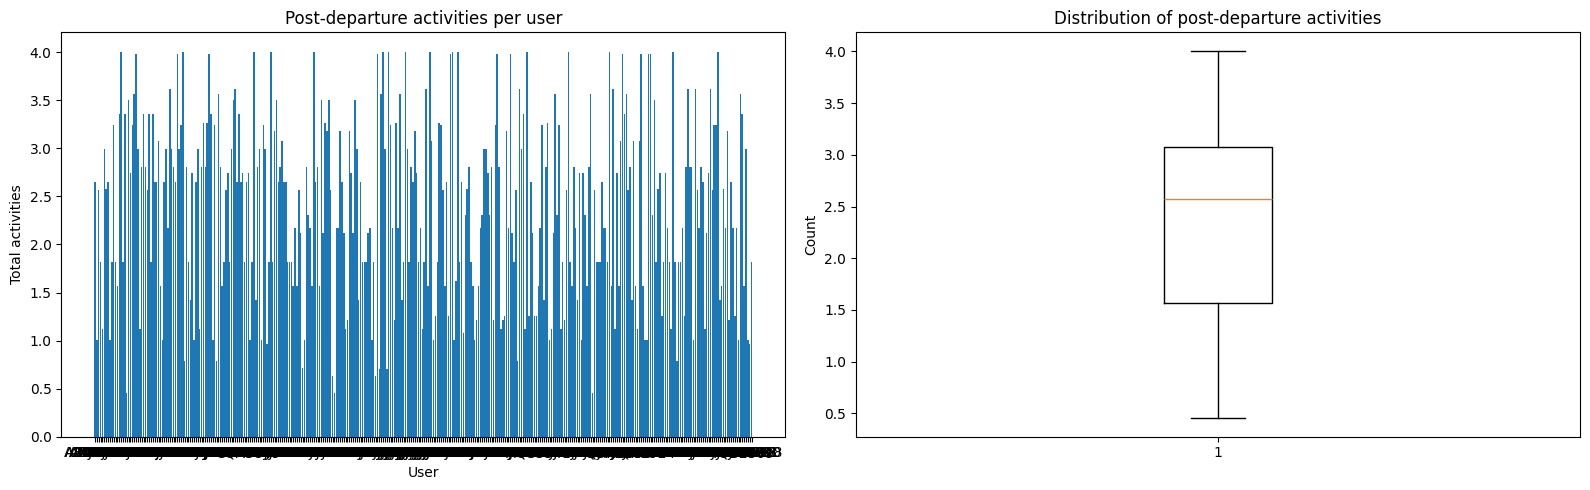

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].bar(features_ldap["user"], features_ldap["ldap_zscore_departure"])
ax[0].set_title("Post-departure activities per user")
ax[0].set_xlabel("User")
ax[0].set_ylabel("Total activities")

ax[1].boxplot(features_ldap["ldap_zscore_departure"])
ax[1].set_title("Distribution of post-departure activities")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
dfs = [features_email,features_file,features_sessions,logon_features,file_decoy_features, features_psycho , features_device,features_http,features_ldap]

df_final = reduce(lambda left, right: pd.merge(left, right, on='user',how='outer'), dfs)
df_final = df_final.fillna(0)

(4000, 82)

In [ ]:
features_v2 = df_final
features_v2.head()

,user,email_nb_emails,email_nb_emails_sent,email_nb_emails_viewed,email_nb_external,email_nb_bcc,email_nb_external_with_attachment,email_nb_after_hours_or_weekend,email_nb_emails_has_suspicious_content,email_external_ratio,...,http_avg_requests_per_day,http_total_keyword_flags,http_upload_ratio,http_download_ratio,http_off_hours_ratio,http_weekend_activity_ratio,http_last_month_activity,http_max_zscore_activity,http_post_departure_activity,http_job_search_score
0,AAB0162,3146,1122,2024,967,0,161,0,220,0.307374,...,95.0,0,0.0,0.0,0.0000,0.0,0,0.0,0,0.0699
1,AAB0398,3811,1348,2463,1462,0,450,215,289,0.383626,...,114.0,0,0.0,0.0,0.0474,0.0,0,0.0,0,0.0133
2,AAC0610,1052,388,664,382,0,139,0,93,0.363118,...,29.0,0,0.0,0.0,0.0096,0.0,0,0.0,0,0.0189
3,AAC0668,3115,1093,2022,1092,0,219,0,331,0.350562,...,95.0,0,0.0,0.0,0.0000,0.0,0,0.0,0,0.0548
4,AAC3270,344,120,224,89,0,48,0,25,0.258721,...,10.0,0,0.0,0.0,0.0000,0.0,0,0.0,0,0.0045


In [7]:
features_v2['users_pre_departure_activity_last_month'] = features_v2['email_nb_emails_last_month'] + features_v2['file_nb_file_last_month'] + features_v2['logon_nb_logon_last_month'] + features_v2['device_nb_device_conn_last_month'] + features_v2['http_last_month_activity']
features_v2['users_post_departure_activity'] = features_v2['email_nb_activity_email_after_leaving'] + features_v2['file_nb_file_after_leaving'] + features_v2['logon_nb_logon_after_leaving'] + features_v2['device_nb_device_activity_after_leaving'] + features_v2['http_post_departure_activity']
features_v2['users_all_activity'] = features_v2['email_nb_emails'] + features_v2['file_nb_file_events'] + features_v2['logon_nb_logon'] + features_v2['device_nb_device_conn'] + features_v2['http_total_activity']
features_v2['users_pre_departure_ratio'] = features_v2['users_pre_departure_activity_last_month'] / features_v2['users_all_activity']

In [9]:
features_v2.shape

(4000, 86)

In [8]:
features_v2.columns

Index(['user', 'email_nb_emails', 'email_nb_emails_sent',
       'email_nb_emails_viewed', 'email_nb_external', 'email_nb_bcc',
       'email_nb_external_with_attachment', 'email_nb_after_hours_or_weekend',
       'email_nb_emails_has_suspicious_content', 'email_external_ratio',
       'email_suspicious_content_ratio', 'email_bcc_email_ratio',
       'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_max_zscore_emails_sent', 'email_avg_emails_per_week',
       'email_avg_size_sent_email', 'email_nb_emails_last_month',
       'email_nb_activity_email_after_leaving', 'file_nb_file_events',
       'file_copy_ratio', 'file_write_ratio', 'file_delete_ratio',
       'file_copy_to_removable_ratio', 'file_from_removable_ratio',
       'file_unique_files_ratio', 'file_events_per_file',
       'file_pc_usage_ratio', 'file_off_hours_ratio',
       'file_suspicious_file_content_ratio', 'file_open_then_copy_ratio',
   

In [42]:
features_v2.to_csv('features_v2.csv',index=False)

In [39]:
features_v2 = pd.read_csv('features_v2.csv')

In [43]:
features_v2.columns

Index(['user', 'email_nb_emails', 'email_nb_emails_sent',
       'email_nb_emails_viewed', 'email_nb_external', 'email_nb_bcc',
       'email_nb_external_with_attachment', 'email_nb_after_hours_or_weekend',
       'email_nb_emails_has_suspicious_content', 'email_external_ratio',
       'email_suspicious_content_ratio', 'email_bcc_email_ratio',
       'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_max_zscore_emails_sent', 'email_avg_emails_per_week',
       'email_avg_size_sent_email', 'email_nb_emails_last_month',
       'email_nb_activity_email_after_leaving', 'file_nb_file_events',
       'file_copy_ratio', 'file_write_ratio', 'file_delete_ratio',
       'file_copy_to_removable_ratio', 'file_from_removable_ratio',
       'file_unique_files_ratio', 'file_events_per_file',
       'file_pc_usage_ratio', 'file_off_hours_ratio',
       'file_suspicious_file_content_ratio', 'file_open_then_copy_ratio',
   

In [44]:
features_v3 = features_v2.drop(columns=['email_nb_emails','email_nb_emails_sent','email_nb_emails_viewed','email_nb_external','email_nb_bcc','email_nb_activity_email_after_leaving',
       'email_nb_external_with_attachment', 'email_nb_after_hours_or_weekend','email_nb_emails_has_suspicious_content','email_nb_emails_last_month','email_max_zscore_emails_sent',
       'file_nb_file_events','file_nb_file_last_month','file_nb_file_after_leaving','logon_nb_short_sessions','logon_nb_sessions','logon_nb_logon','logon_nb_logoff','logon_nb_pc_used',
       'logon_nb_after_hours_logon','logon_nb_logon_last_month','device_nb_device_conn','device_nb_device_conn_last_month','device_avg_zscore_device_week','device_nb_device_conn_after_hours',
       'http_total_activity','http_last_month_activity','users_all_activity','users_pre_departure_activity_last_month','email_nb_activity_email_after_leaving','file_nb_file_after_leaving',
       'logon_nb_logon_after_leaving','device_nb_device_activity_after_leaving','http_post_departure_activity','http_total_weighted_activity','users_is_electronic_security','logon_nb_pc_used_logon',
       'decoy_file_nb_pc_decoy_file'
       ])
features_v3.shape

(4000, 51)

In [45]:
features_v3.columns

Index(['user', 'email_external_ratio', 'email_suspicious_content_ratio',
       'email_bcc_email_ratio', 'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_avg_emails_per_week', 'email_avg_size_sent_email',
       'file_copy_ratio', 'file_write_ratio', 'file_delete_ratio',
       'file_copy_to_removable_ratio', 'file_from_removable_ratio',
       'file_unique_files_ratio', 'file_events_per_file',
       'file_pc_usage_ratio', 'file_off_hours_ratio',
       'file_suspicious_file_content_ratio', 'file_open_then_copy_ratio',
       'file_write_then_delete_ratio', 'file_copy_then_delete_ratio',
       'file_max_zscore_file_activity', 'logon_average_session_duration',
       'logon_session_duration_variability', 'logon_ratio_short_sessions',
       'logon_used_multi_pc_simultaneously', 'logon_unclosed_session_ratio',
       'logon_after_hours_logon_ratio', 'logon_max_zscore_logon',
       'logon_max_zscore_logo

In [46]:
features_v3.to_csv('features_v3.csv',index=False)

In [ ]:
df = pd.read_csv('features_v3.csv')
df.head()

,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,file_copy_ratio,...,http_total_keyword_flags,http_upload_ratio,http_download_ratio,http_off_hours_ratio,http_max_zscore_activity,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio,logon_nb_pc_used_logon_ratio,decoy_file_nb_pc_decoy_file_ratio
0,AAB0162,0.307374,0.069930,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,0.000000,...,0,0.0,0.0,0.0000,0.0,0.0699,0.0,0.000000,0.002817,0.033333
1,AAB0398,0.383626,0.075833,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,0.000000,...,0,0.0,0.0,0.0474,0.0,0.0133,0.0,0.000000,0.002809,0.027778
2,AAC0610,0.363118,0.088403,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.445705,...,0,0.0,0.0,0.0096,0.0,0.0189,0.0,0.001404,0.001504,0.005236
3,AAC0668,0.350562,0.106260,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.000000,...,0,0.0,0.0,0.0000,0.0,0.0548,0.0,0.000000,0.002809,0.016129
4,AAC3270,0.258721,0.072674,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.000000,...,0,0.0,0.0,0.0000,0.0,0.0045,0.0,0.000000,0.002809,0.125000


In [22]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders = l[l['dataset']==6.2]['user']
insiders

186    ACM2278
187    CMP2946
188    PLJ1771
189    CDE1846
190    MBG3183
Name: user, dtype: object

In [27]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

is_insider
0    3995
1       5
Name: count, dtype: int64

In [3]:
X = df.drop(columns='user')

s_scaler = StandardScaler()

m_scaler = MinMaxScaler()

X_scaled_s = s_scaler.fit_transform(X)

X_scaled_m = m_scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=1000,
    max_samples=2000,
    max_features=1.0,
    random_state=42
)

model.fit(X_scaled_s)

IsolationForest(max_samples=2000, n_estimators=1000, random_state=42)

In [4]:
df['anomaly_score'] = -model.score_samples(X_scaled_s)

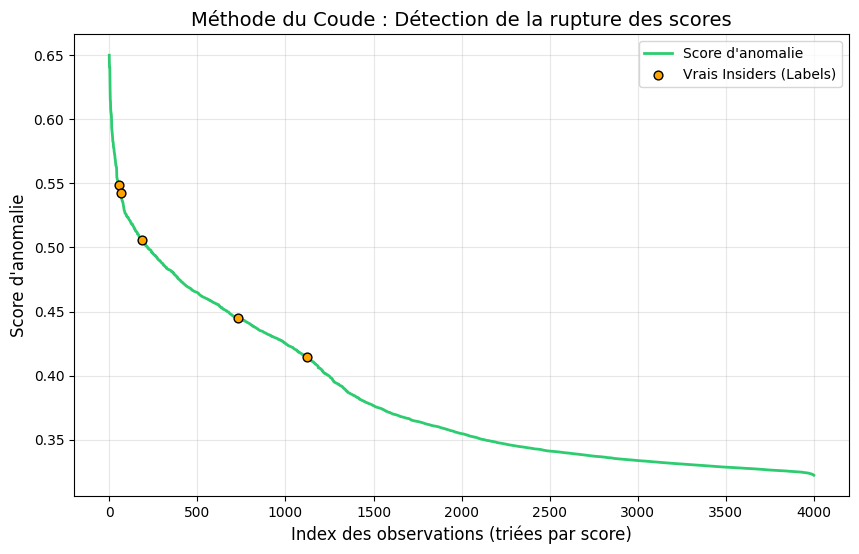

In [47]:
sorted_indices = np.argsort(df['anomaly_score'].values)[::-1]

sorted_scores = df['anomaly_score'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)
plt.xlabel("Index des observations (triées par score)", fontsize=12)
plt.ylabel("Score d'anomalie", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()